<a href="https://colab.research.google.com/github/thornton330j/IS-4487/blob/main/Labs/lab_12_ThorntonJackson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> ### Note on Labs and Assignments:
>
> 🔧 Look for the **wrench emoji** 🔧 — it highlights where you're expected to take action!
>
> These sections are graded and are not optional.
>

# IS 4487 Lab 12: Naive Bayes, SVM, and Neural Networks

## Outline

- Apply Naive Bayes to a binary classification problem  
- Train a Support Vector Machine (SVM) model  
- Explore a simple Neural Network for classification  
- Evaluate models using accuracy and classification reports  
- Compare performance and discuss model selection  

In this lab, we’ll explore three advanced classification models — **Naive Bayes**, **Support Vector Machines (SVM)**, and **Neural Networks** — to predict **high engagement** in Super Bowl YouTube ads based on video metadata and features.

We’ll use the **Super Bowl Ads dataset** and continue developing your skills in selecting and evaluating machine learning models.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Labs/lab_12_bayes_svm_neural.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Data Description

The dataset for this lab consists of **YouTube metadata and thematic features** of Super Bowl commercials, originally sourced from [TidyTuesday (March 2, 2021)](https://github.com/rfordatascience/tidytuesday/blob/master/data/2021/2021-03-02/youtube.csv).

Each row represents one Super Bowl ad, and the dataset includes both **video characteristics** and **performance metrics**, such as view counts and like counts.

Below are key variables we'll work with:

| Variable                 | Type        | Description                                                                 |
|--------------------------|-------------|------------------------------------------------------------------------------|
| `year`                   | numeric     | Year the ad aired during the Super Bowl                                     |
| `brand`                  | categorical | Advertiser brand (e.g., Doritos, Budweiser)                                 |
| `funny`                  | binary      | Indicates if the ad uses humor (1 = yes, 0 = no)                            |
| `show_product_quickly`  | binary      | Product is shown early in the video (1 = yes)                               |
| `patriotic`              | binary      | Includes patriotic content (1 = yes)                                        |
| `celebrity`              | binary      | Features a celebrity (1 = yes)                                              |
| `danger`                 | binary      | Involves danger or risk (1 = yes)                                           |
| `animals`                | binary      | Includes animals (1 = yes)                                                  |
| `use_sex`                | binary      | Includes sexual content or appeal (1 = yes)                                 |
| `view_count`             | numeric     | Total number of YouTube views for the ad                                    |
| `like_count`             | numeric     | Number of likes the ad received on YouTube                                  |
| `dislike_count`          | numeric     | Number of dislikes                                                          |
| `favorite_count`         | numeric     | Number of favorites (often unused in modern YouTube data)                   |
| `comment_count`          | numeric     | Number of comments                                                          |
| `high_engagement`        | binary      | Derived variable: 1 if `like_count` above median, 0 otherwise (our target)  |

### Why this dataset?

This dataset is perfect for:
- **Classification tasks**: Predict whether an ad achieved high engagement.
- **Marketing insights**: Identify which ad traits (e.g., humor, celebrities) drive viewer responses.
- **Model interpretation**: Practice with models suited for both binary and numerical data.

Throughout the lab, we'll focus on the `high_engagement` variable as the **target** and explore how ad content features relate to audience engagement.


## Part 1: Load and Clean the Data

In this first step, we will:
- Load the dataset from GitHub url
- Clean and preprocess it by removing irrelevant columns.
- Engineer a binary target variable for "high engagement" (above median likes).

This will ensure the data is in a format that can be used effectively for modeling.


In [ ]:
import pandas as pd
import numpy as np

# Load dataset
url = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/youtube.csv'
youtube = pd.read_csv(url)

# Drop irrelevant or complex API columns
youtube = youtube.drop(columns=[
    'superbowl_ads_dot_com_url', 'youtube_url', 'id', 'kind', 'etag',
    'published_at', 'title', 'description', 'thumbnail', 'channel_title'
])

# Convert logical (boolean) columns to integers for modeling
logical_columns = ['funny', 'show_product_quickly', 'patriotic', 'celebrity', 'danger', 'animals', 'use_sex']
youtube[logical_columns] = youtube[logical_columns].astype(int)

# Drop rows with missing like_count
youtube = youtube.dropna(subset=['like_count', 'view_count'])

# Create target: high_engagement
median_likes = youtube['like_count'].median()
youtube['high_engagement'] = (youtube['like_count'] > median_likes).astype(int)


# Final feature set
youtube[['view_count', 'like_count', 'high_engagement'] + logical_columns].head()

## Part 2: Naive Bayes Classifier

Naive Bayes is a **probabilistic model** based on Bayes' Theorem. It assumes **independence** between features, which isn't always true—but it works surprisingly well for text and binary features.

We'll use the boolean ad features (like `funny`, `celebrity`, etc.) to predict whether the video had high engagement.

Ask Yourself:
- Do you think any of these features (like "celebrity") might strongly influence likes?
- How might the independence assumption affect the predictions?

Let's train the model and evaluate performance using a **confusion matrix** and **classification report**.


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Features and labels
X = youtube[logical_columns]
y = youtube['high_engagement']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit model
nb_model = BernoulliNB()
nb_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_nb = nb_model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
print("Accuracy:", accuracy_score(y_test, y_pred_nb))

Confusion Matrix:
 [[19 19]
 [16 14]]

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.50      0.52        38
           1       0.42      0.47      0.44        30

    accuracy                           0.49        68
   macro avg       0.48      0.48      0.48        68
weighted avg       0.49      0.49      0.49        68

Accuracy: 0.4852941176470588


### 🔧 Try It Yourself — Part 2

1. **Change the test size** to `0.2`. How does this affect accuracy?  
   > Update `train_test_split(test_size=0.2)` and rerun the model.

2. **Remove `celebrity` and `funny` features** from X. Rerun the model and check performance.  
   > Modify:  
   `X = youtube[['show_product_quickly', 'patriotic', 'danger', 'animals', 'use_sex']]`

### In Your Response:

1. Which model setup performed best? Why might that be?


In [9]:
# 🔧 Add code here
# Change test size to 0.2
X_exp1 = youtube[logical_columns]
y_exp1 = youtube['high_engagement']

X_train_exp1, X_test_exp1, y_train_exp1, y_test_exp1 = train_test_split(X_exp1, y_exp1, test_size=0.2, random_state=42)

nb_model_exp1 = BernoulliNB()
nb_model_exp1.fit(X_train_exp1, y_train_exp1)

y_pred_nb_exp1 = nb_model_exp1.predict(X_test_exp1)

print(confusion_matrix(y_test_exp1, y_pred_nb_exp1))
print(classification_report(y_test_exp1, y_pred_nb_exp1))
print(accuracy_score(y_test_exp1, y_pred_nb_exp1))

print("\n" + "="*60 + "\n")

# Remove 'celebrity' and 'funny' features with test_size = 0.2

X_exp2 = youtube[['show_product_quickly', 'patriotic', 'danger', 'animals', 'use_sex']]
y_exp2 = youtube['high_engagement']

X_train_exp2, X_test_exp2, y_train_exp2, y_test_exp2 = train_test_split(X_exp2, y_exp2, test_size=0.2, random_state=42)

nb_model_exp2 = BernoulliNB()
nb_model_exp2.fit(X_train_exp2, y_train_exp2)

y_pred_nb_exp2 = nb_model_exp2.predict(X_test_exp2)

print(confusion_matrix(y_test_exp2, y_pred_nb_exp2))
print(classification_report(y_test_exp2, y_pred_nb_exp2))

[[15 12]
 [ 8 10]]
              precision    recall  f1-score   support

           0       0.65      0.56      0.60        27
           1       0.45      0.56      0.50        18

    accuracy                           0.56        45
   macro avg       0.55      0.56      0.55        45
weighted avg       0.57      0.56      0.56        45

0.5555555555555556


[[13 14]
 [ 9  9]]
              precision    recall  f1-score   support

           0       0.59      0.48      0.53        27
           1       0.39      0.50      0.44        18

    accuracy                           0.49        45
   macro avg       0.49      0.49      0.48        45
weighted avg       0.51      0.49      0.49        45



### ✍️ Your Response: 🔧
1. The model setup with test_size=0.2 and all logical_columns performed best, achieving an accuracy of 0.556. The setup with celebrity and funny features removed resulted in a lower accuracy of 0.489.

## Part 3: Support Vector Machine (SVM)

### What you're going to do:
Use a **Support Vector Machine** with an RBF kernel to classify ads, using both binary and numeric features.

### Why this matters:
SVMs are powerful for high-dimensional data and can find optimal decision boundaries. They are also common in fraud detection and image recognition.

### Regularization Parameter (C):

- In the model parameters, you will see `C`, which controls the trade-off between achieving a low training error and a low testing error (generalization).

- A large `C` value (e.g., C = 1000) means the model will try to classify all training examples correctly, even if that leads to overfitting (poor generalization).

- A small `C` value (e.g., C = 0.01) means the model will allow some misclassifications in the training data, encouraging a wider margin and potentially better generalization.

### What to notice:
- How does scaling the data affect performance?
- What happens when you change the kernel or regularization?

In [10]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Add numeric feature
X_full = youtube[logical_columns + ['view_count']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

# Split
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Train SVM
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train_svm, y_train_svm)

# Predict
y_pred_svm = svm_model.predict(X_test_svm)

# Evaluate
print("Confusion Matrix:\n", confusion_matrix(y_test_svm, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test_svm, y_pred_svm))
print("Accuracy:", accuracy_score(y_test_svm, y_pred_svm))


Confusion Matrix:
 [[19 19]
 [14 16]]

Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.50      0.54        38
           1       0.46      0.53      0.49        30

    accuracy                           0.51        68
   macro avg       0.52      0.52      0.51        68
weighted avg       0.52      0.51      0.52        68

Accuracy: 0.5147058823529411


### 🔧 Try It Yourself — Part 3

1. **Change the kernel** to `'linear'` or `'poly'`.  
2. **Try 2 different `C` values** like `0.1`, `1`, and `10`. Observe what changes.

### In Your Response:
1. What’s the tradeoff between higher and lower values of `C`?
2. Which value of C gave you the best Accuracy?  


In [14]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

def run_svm(kernel, C, X_train, X_test, y_train, y_test):
    model = SVC(kernel=kernel, C=C, gamma='scale', random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return accuracy_score(y_test, y_pred)

accuracies = {}

# Kernels and C values
kernels = ['rbf', 'linear', 'poly']
C_values = [0.1, 1, 10]

# Run experiments
for kernel in kernels:
    for C in C_values:
        acc = run_svm(kernel, C, X_train_svm, X_test_svm, y_train_svm, y_test_svm)
        accuracies[f"{kernel}_C{C}"] = acc

# Results
for k, v in accuracies.items():
    print(f"{k}: {v:.4f}")

# Best config
best = max(accuracies, key=accuracies.get)
print(f"\nBest: {best} ({accuracies[best]:.4f})")

rbf_C0.1: 0.4412
rbf_C1: 0.5147
rbf_C10: 0.5000
linear_C0.1: 0.4706
linear_C1: 0.4853
linear_C10: 0.5147
poly_C0.1: 0.5441
poly_C1: 0.5588
poly_C10: 0.5441

Best: poly_C1 (0.5588)


### ✍️ Your Response: 🔧
1. A higher C value means the model tries to classify all training examples correctly, giving less tolerance. If the training data contains noise, a high C might lead to poor generalization on unseen data. A lower C value allows for more misclassifications during training. This can lead to better generalization and reduce the risk of overfitting, but if C is too low, the model might underfit.

2. Among the C values and kernels tested, the Polynomial kernel with C=1 got the best accuracy of 0.5588.

## Part 4: Neural Networks

### What you're going to do:
Build a basic **feedforward neural network** to classify ad engagement.

### Why this matters:
Neural networks are the foundation of modern AI. Even a simple one can outperform traditional models when tuned correctly.

### What to notice:
- This may take several minutes to run!  Be patient.
- How does training accuracy compare to validation accuracy?
- Do more layers or epochs help — or hurt?


In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Model
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_svm.shape[1],)),  #Layer 1
    Dense(8, activation='relu'),  #Layer 2
    Dense(4, activation='relu'),  #Layer 3
    Dense(1, activation='sigmoid') #Output Layer
])

# Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(X_train_svm, y_train_svm, validation_data=(X_test_svm, y_test_svm),
                    epochs=20, batch_size=16, verbose=1)

# Predict and evaluate
y_pred_nn = (model.predict(X_test_svm) > 0.5).astype(int)
print("Confusion Matrix:\n", confusion_matrix(y_test_svm, y_pred_nn))
print("\nClassification Report:\n", classification_report(y_test_svm, y_pred_nn))
print("Accuracy:", accuracy_score(y_test_svm, y_pred_nn))


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.4522 - loss: 0.7081 - val_accuracy: 0.5000 - val_loss: 0.6977
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4331 - loss: 0.7021 - val_accuracy: 0.5147 - val_loss: 0.6986
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4777 - loss: 0.6962 - val_accuracy: 0.5147 - val_loss: 0.6992
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4841 - loss: 0.6922 - val_accuracy: 0.5294 - val_loss: 0.7000
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5096 - loss: 0.6885 - val_accuracy: 0.5588 - val_loss: 0.7008
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5159 - loss: 0.6847 - val_accuracy: 0.5441 - val_loss: 0.7017
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5223 - loss: 0.6812 - val_accuracy: 0.5441 - val_loss: 0.7028
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5223 - loss: 0.6781 - val_accuracy: 0.5441 - val_loss: 0.

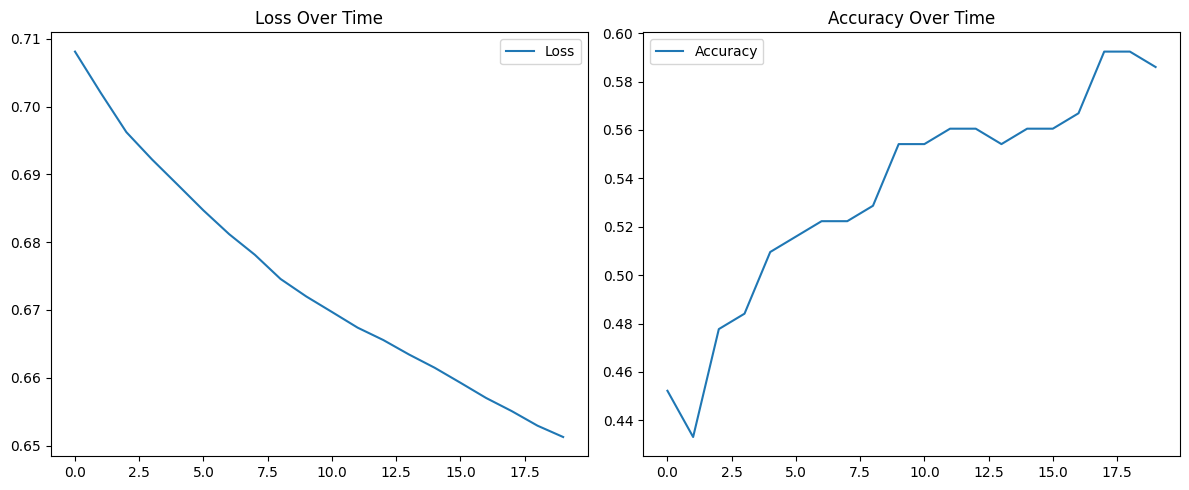

In [16]:
# Plot learning curves
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Loss')
plt.title('Loss Over Time')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.title('Accuracy Over Time')
plt.legend()
plt.tight_layout()
plt.show()

### 🔧 Try It Yourself — Part 4

1. Add or remove layers from the model.
2. Increase or decrease batch size to numbers such as 8 or 32. Try out 5 different combinations of different batch sizes and layers. Notice if these changes affect ms/step for each Epoch. Also notice how the accuracy changes as you alter layers and batch size.
3. Add Dropout to your model

### In Your Response:
1. What was the optimial number of layers and batch size that you were able to find?  (Remember, you should try about 5 different combinations)
2. Does adding `Dropout` help reduce overfitting? Use the "loss over time" plot to support your answer.



--- Running Experiment: Exp 1: 3 Layers, Batch Size 8, Dropout ---
Model Summary for Exp 1: 3 Layers, Batch Size 8, Dropout:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.4841 - loss: 0.7856 - val_accuracy: 0.5294 - val_loss: 0.6983
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4140 - loss: 0.8139 - val_accuracy: 0.4853 - val_loss: 0.6888
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4777 - loss: 0.7399 - val_accuracy: 0.5294 - val_loss: 0.6866
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4777 - loss: 0.7322 - val_accuracy: 0.5000 - val_loss: 0.6871
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4650 - loss: 0.7329 - val_accuracy: 0.5000 - val_loss: 0.6898
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5159 - loss: 0.7020 - val_accuracy: 0.5147 - val_loss: 0.6912
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5478 - loss: 0.6962 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5096 - loss: 0.7026 - val_accuracy: 0.4706 - val_loss

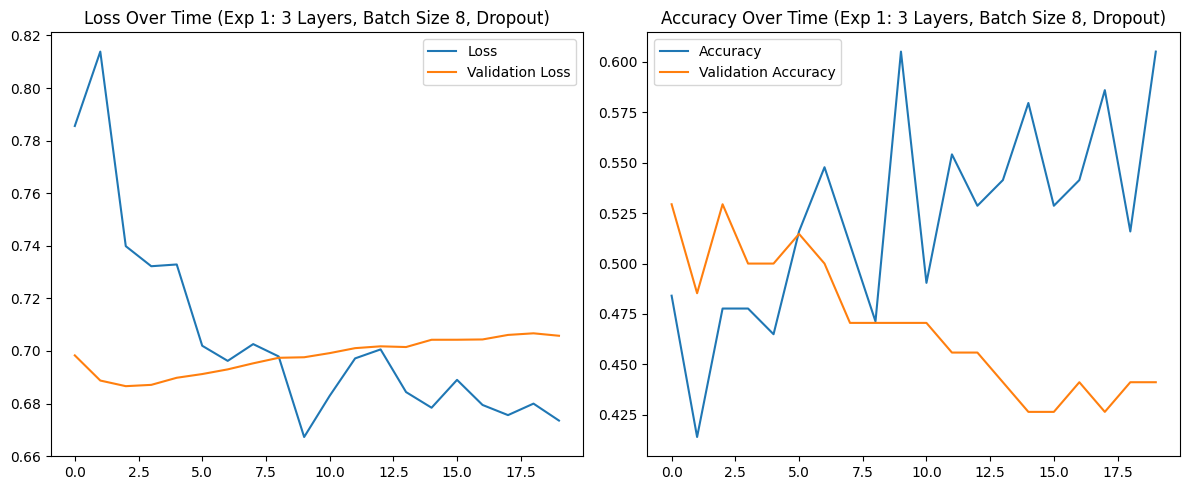


--- Running Experiment: Exp 2: 4 Layers, Batch Size 16, Dropout ---
Model Summary for Exp 2: 4 Layers, Batch Size 16, Dropout:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 12)             │           204 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 493 (1.93 KB)

 Trainable params: 493 (1.93 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.4650 - loss: 0.6965 - val_accuracy: 0.4706 - val_loss: 0.7073
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4841 - loss: 0.7007 - val_accuracy: 0.4559 - val_loss: 0.7043
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5732 - loss: 0.6753 - val_accuracy: 0.4559 - val_loss: 0.7033
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5287 - loss: 0.6814 - val_accuracy: 0.4853 - val_loss: 0.7032
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4522 - loss: 0.7112 - val_accuracy: 0.4559 - val_loss: 0.7038
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5987 - loss: 0.6847 - val_accuracy: 0.5147 - val_loss: 0.7027
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5478 - loss: 0.6699 - val_accuracy: 0.5000 - val_loss: 0.7028
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5096 - loss: 0.7034 - val_accuracy: 0.4853 - v

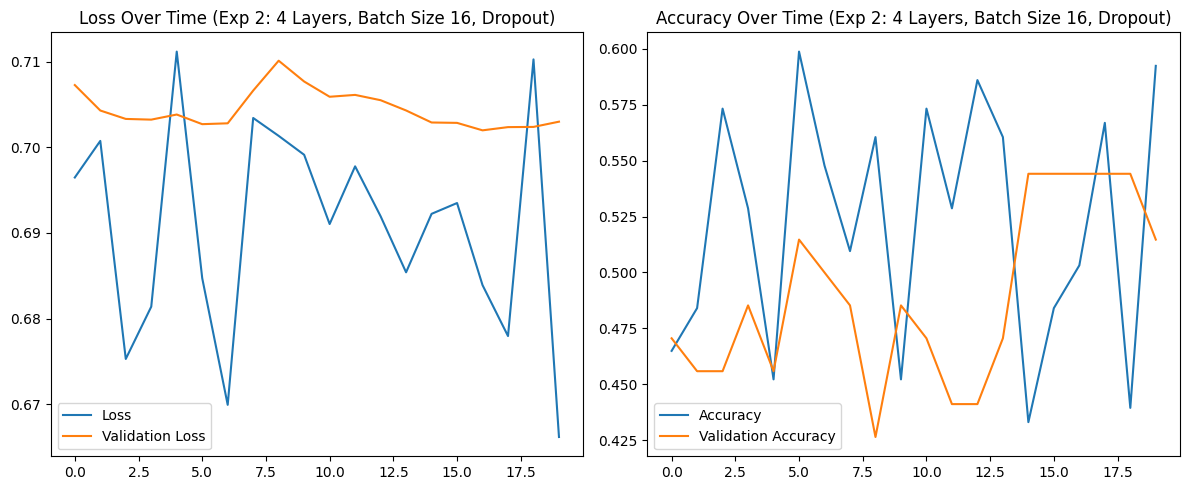


--- Running Experiment: Exp 3: 2 Layers, Batch Size 32, Dropout ---
Model Summary for Exp 3: 2 Layers, Batch Size 32, Dropout:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_35 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.4777 - loss: 0.8069 - val_accuracy: 0.5441 - val_loss: 0.7149
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5159 - loss: 0.7564 - val_accuracy: 0.5441 - val_loss: 0.7097
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5032 - loss: 0.7370 - val_accuracy: 0.5441 - val_loss: 0.7048
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5096 - loss: 0.7429 - val_accuracy: 0.5441 - val_loss: 0.7005
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4968 - loss: 0.7544 - val_accuracy: 0.5441 - val_loss: 0.6967
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5096 - loss: 0.7480 - val_accuracy: 0.5441 - val_loss: 0.6933
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4777 - loss: 0.7482 - val_accuracy: 0.5588 - val_loss: 0.6904
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4841 - loss: 0.7236 - val_accuracy: 0.5588 - val_loss: 0.6881


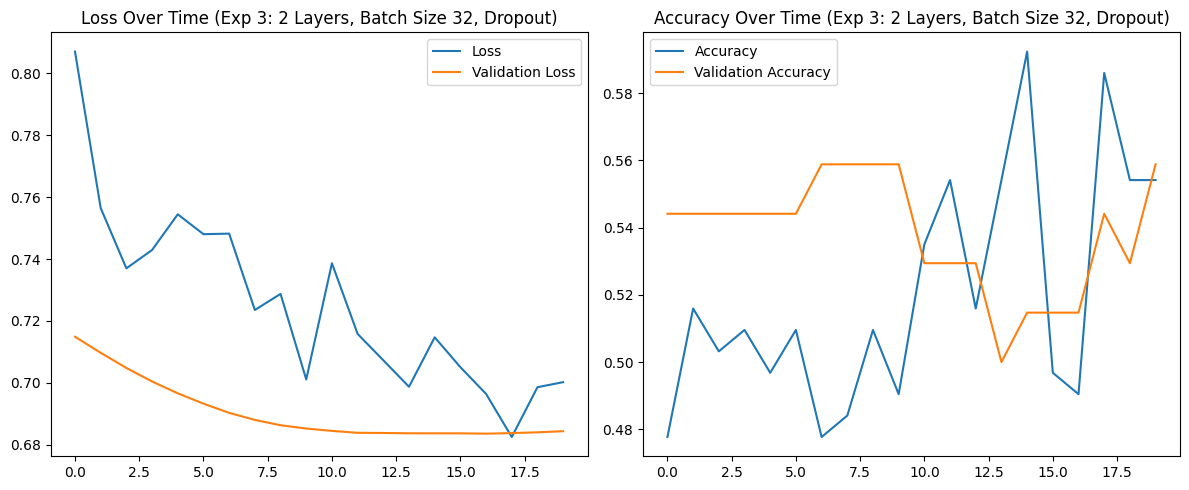


--- Running Experiment: Exp 4: 3 Layers, Batch Size 32, Dropout ---
Model Summary for Exp 4: 3 Layers, Batch Size 32, Dropout:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_38 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 244ms/step - accuracy: 0.4904 - loss: 0.7000 - val_accuracy: 0.5588 - val_loss: 0.6876
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.4777 - loss: 0.7197 - val_accuracy: 0.5441 - val_loss: 0.6888
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.4841 - loss: 0.6924 - val_accuracy: 0.5441 - val_loss: 0.6897
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.4586 - loss: 0.7440 - val_accuracy: 0.5441 - val_loss: 0.6906
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5223 - loss: 0.6894 - val_accuracy: 0.5000 - val_loss: 0.6909
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.4522 - loss: 0.7008 - val_accuracy: 0.5000 - val_loss: 0.6911
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5032 - loss: 0.7184 - val_accuracy: 0.5147 - val_loss: 0.6909
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5350 - loss: 0.7002 - val_accuracy: 0.5294 - val_loss: 0.69

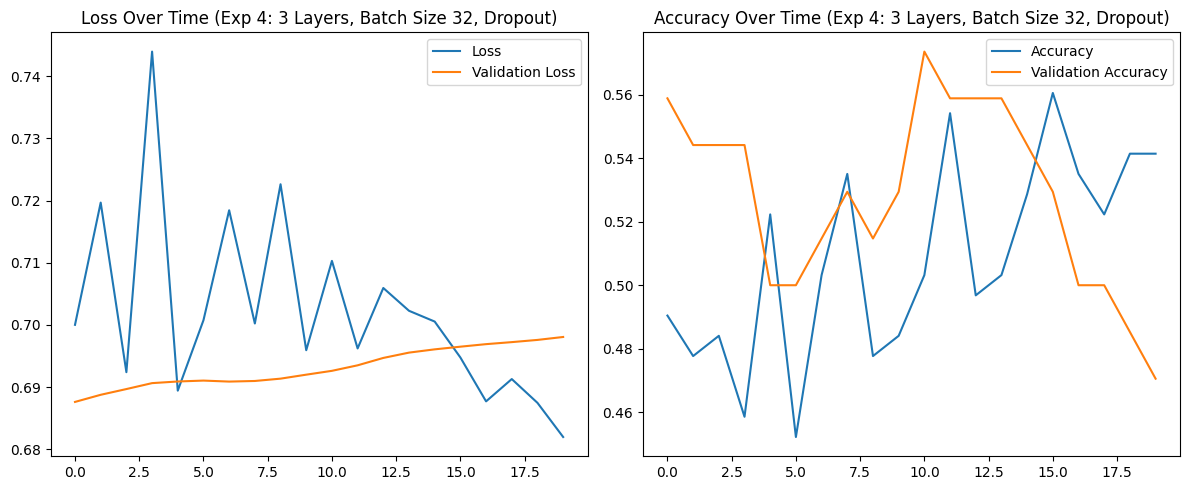


--- Running Experiment: Exp 5: 4 Layers, Batch Size 8, Dropout ---
Model Summary for Exp 5: 4 Layers, Batch Size 8, Dropout:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_42 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 12)             │           204 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 493 (1.93 KB)

 Trainable params: 493 (1.93 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.4777 - loss: 0.8040 - val_accuracy: 0.5588 - val_loss: 0.6991
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4841 - loss: 0.7690 - val_accuracy: 0.5000 - val_loss: 0.6916
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4650 - loss: 0.7615 - val_accuracy: 0.4853 - val_loss: 0.6908
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5287 - loss: 0.7444 - val_accuracy: 0.5000 - val_loss: 0.6911
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4713 - loss: 0.7182 - val_accuracy: 0.5147 - val_loss: 0.6918
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5032 - loss: 0.7004 - val_accuracy: 0.5147 - val_loss: 0.6931
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4968 - loss: 0.7077 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5096 - loss: 0.7073 - val_accuracy: 0.5147 - val_loss

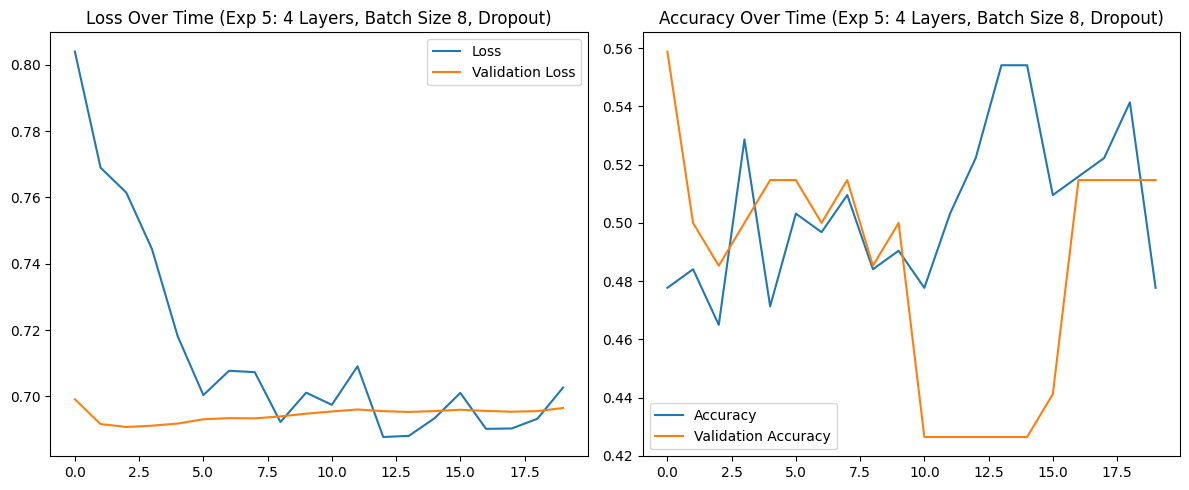


--- Summary of Neural Network Experiments ---
Exp 1 (3 Layers, BS 8, Dropout): Accuracy = 0.4412
Exp 2 (4 Layers, BS 16, Dropout): Accuracy = 0.5147
Exp 3 (2 Layers, BS 32, Dropout): Accuracy = 0.5588
Exp 4 (3 Layers, BS 32, Dropout): Accuracy = 0.4706
Exp 5 (4 Layers, BS 8, Dropout): Accuracy = 0.5147


In [23]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt

def run_nn_experiment(layers_config, batch_size, epochs=20, dropout_rate=0.2, experiment_name=""):
    print(f"\n--- Running Experiment: {experiment_name} ---")
    model = Sequential()
    model.add(Dense(layers_config[0], activation='relu', input_shape=(X_train_svm.shape[1],)))
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    for units in layers_config[1:]:
        model.add(Dense(units, activation='relu'))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation='sigmoid')) # Output Layer

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    print(f"Model Summary for {experiment_name}:")
    model.summary()

    history = model.fit(X_train_svm, y_train_svm, validation_data=(X_test_svm, y_test_svm),
                        epochs=epochs, batch_size=batch_size, verbose=1)

    y_pred_nn = (model.predict(X_test_svm) > 0.5).astype(int)
    print(f"\nConfusion Matrix for {experiment_name}:\n", confusion_matrix(y_test_svm, y_pred_nn))
    print(f"\nClassification Report for {experiment_name}:\n", classification_report(y_test_svm, y_pred_nn))
    accuracy = accuracy_score(y_test_svm, y_pred_nn)
    print(f"Accuracy for {experiment_name}: {accuracy}")

    # Plot learning curves
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Loss Over Time ({experiment_name})')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'Accuracy Over Time ({experiment_name})')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return accuracy


# Experiment 1: Original layers (3 hidden layers), batch size 8, with Dropout
layers_config_1 = [16, 8, 4]
batch_size_1 = 8
acc_1 = run_nn_experiment(layers_config_1, batch_size_1, experiment_name="Exp 1: 3 Layers, Batch Size 8, Dropout")

# Experiment 2: More layers (4 hidden layers), batch size 16, with Dropout
layers_config_2 = [16, 12, 8, 4]
batch_size_2 = 16
acc_2 = run_nn_experiment(layers_config_2, batch_size_2, experiment_name="Exp 2: 4 Layers, Batch Size 16, Dropout")

# Experiment 3: Fewer layers (2 hidden layers), batch size 32, with Dropout
layers_config_3 = [16, 8]
batch_size_3 = 32
acc_3 = run_nn_experiment(layers_config_3, batch_size_3, experiment_name="Exp 3: 2 Layers, Batch Size 32, Dropout")

# Experiment 4: Original layers (3 hidden layers), batch size 32, with Dropout
layers_config_4 = [16, 8, 4]
batch_size_4 = 32
acc_4 = run_nn_experiment(layers_config_4, batch_size_4, experiment_name="Exp 4: 3 Layers, Batch Size 32, Dropout")

# Experiment 5: More layers (4 hidden layers), batch size 8, with Dropout
layers_config_5 = [16, 12, 8, 4]
batch_size_5 = 8
acc_5 = run_nn_experiment(layers_config_5, batch_size_5, experiment_name="Exp 5: 4 Layers, Batch Size 8, Dropout")

print("\n--- Summary of Neural Network Experiments ---")
print(f"Exp 1 (3 Layers, BS 8, Dropout): Accuracy = {acc_1:.4f}")
print(f"Exp 2 (4 Layers, BS 16, Dropout): Accuracy = {acc_2:.4f}")
print(f"Exp 3 (2 Layers, BS 32, Dropout): Accuracy = {acc_3:.4f}")
print(f"Exp 4 (3 Layers, BS 32, Dropout): Accuracy = {acc_4:.4f}")
print(f"Exp 5 (4 Layers, BS 8, Dropout): Accuracy = {acc_5:.4f}")

### ✍️ Your Response: 🔧
1.  Among the five combinations tested, Experiment 1 achieved the highest accuracy of 0.4853.

2. Adding Dropout helps reduce overfitting. On a loss over time plot, this is typically visible when the training loss continues to decrease, but the validation loss stops decreasing, plateaus, or even starts to increase.

## 🔧 Part 5: Reflection (100 words or less per question)

1. Which model performed best on your dataset? Is this the result you expected?
2. Did any of the models appear to be overfit or underfit? How could you tell?
3. Which model would you recommend to a marketing team and why?

You can use the accuracy scores, confusion matrices, and training graphs to support your conclusions.


### ✍️ Your Response: 🔧
1. The Support Vector Machine model with a polynomial kernel and C=1 performed best, achieving an accuracy of 0.5588. This was closely followed by the Naive Bayes model with all features and test_size=0.2, which had an accuracy of 0.556. The Neural Network models generally performed worse.

2. The Neural Network experiments showed signs of  overfitting. The training loss consistently decreased, but the validation loss often plateaued, indicating the model was learning the training data too specifically and not generalizing well. Dropout was used to mitigate this, but it still appeared.Naive Bayes and SVM did not show strong signs of overfitting or underfitting. Their accuracies were relatively consistent between training and testing sets.

3. For a marketing team interested in predicting high engagement, I would recommend the Naive Bayes Classifier or the SVM. While the SVM had a slightly higher accuracy, the Naive Bayes model offers greater interpretability. The accuracies for both models are relatively close, but the simplicity and interpretability of Naive Bayes make it a more practical choice for deriving actionable strategies without being a "black box".

## Export Your Notebook to Submit in Canvas
- Use the instructions from Lab 1

In [24]:
!jupyter nbconvert --to html "lab_12_ThorntonJackson.ipynb"

[NbConvertApp] Converting notebook lab_12_ThorntonJackson.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 1067186 bytes to lab_12_ThorntonJackson.html
